In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load the California Housing dataset directly from scikit-learn
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

print(f"Dataset Dimensions: {df.shape}")
df.head()

Dataset Dimensions: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Checking for missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


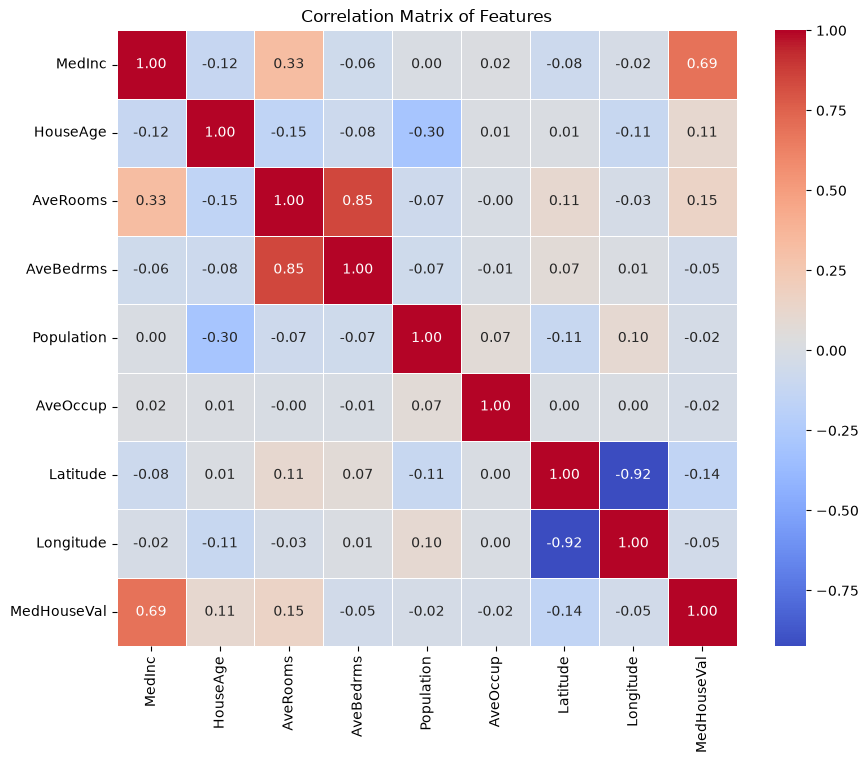

In [4]:
# Check for null values
print("Checking for missing values:")
print(df.isnull().sum())

# Display basic statistics to understand scale and outliers
print("\nStatistical Summary:")
display(df.describe())

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()

In [5]:
# Separate features and target
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Train/test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


In [9]:
# Initialize and fit Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# metrics
mae = mean_absolute_error(y_test, y_pred)

# Calculate RMSE by taking the square root of MSE (removes warnings/errors)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)
print(f"MAE:{mae:.3f} RMSE:{rmse:.3f} R2:{r2:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Coefficient (R²): {r2:.4f}")

MAE:0.533 RMSE:0.746 R2:0.576
Root Mean Squared Error (RMSE): 0.7456
R-squared Coefficient (R²): 0.5758


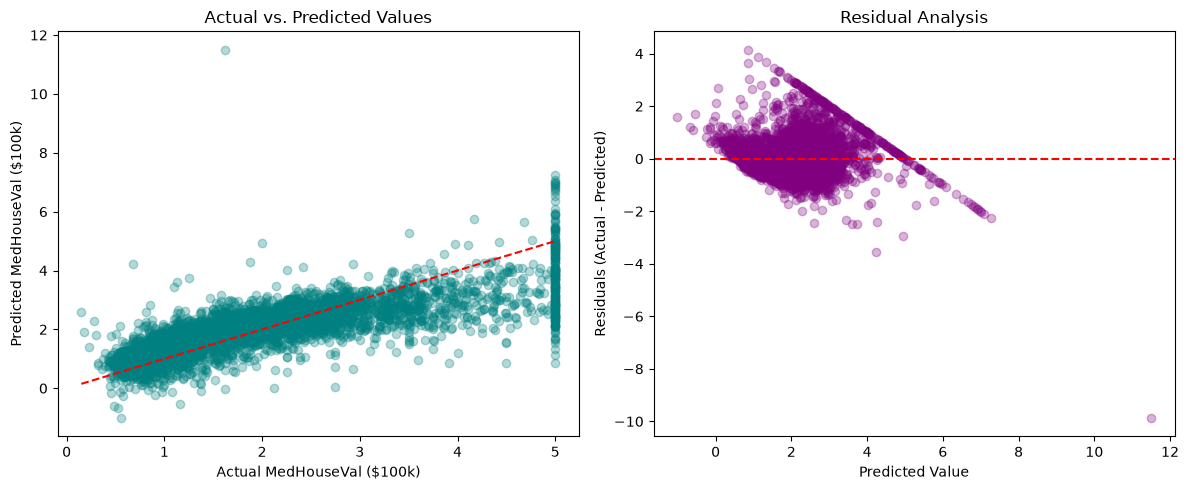

In [7]:
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs. Predicted Values
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual MedHouseVal ($100k)")
plt.ylabel("Predicted MedHouseVal ($100k)")
plt.title("Actual vs. Predicted Values")

# Plot 2: Residual Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Value")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

In [8]:
# Save the model object to disk
with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model successfully saved as 'linear_regression_model.pkl'")

Model successfully saved as 'linear_regression_model.pkl'


In [9]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

# Load the saved model
with open('linear_regression_model.pkl', 'rb') as file:
    model = pickle.load(file)

st.title("California House Price Predictor")
st.write("Input housing parameters below to predict the median house value.")

# Create input fields for the 8 features
med_inc = st.number_input("Median Income (in $10,000s)", value=3.5)
house_age = st.number_input("Median House Age", value=28.0)
ave_rooms = st.number_input("Average Rooms per Dwelling", value=5.0)
ave_bedrms = st.number_input("Average Bedrooms per Dwelling", value=1.0)
population = st.number_input("Block Population", value=1400.0)
ave_occup = st.number_input("Average House Occupancy", value=3.0)
latitude = st.number_input("Block Latitude", value=35.6)
longitude = st.number_input("Block Longitude", value=-119.5)

if st.button("Predict Price"):
    features = np.array([[med_inc, house_age, ave_rooms, ave_bedrms, population, ave_occup, latitude, longitude]])
    prediction = model.predict(features)[0]
    predicted_val = max(0, prediction) * 100000
    st.success(f"Predicted Median House Value: ${predicted_val:,.2f}")

Writing app.py
